# PyCaret para Agrupamento


## Instalação e configuração da biblioteca

In [ ]:
!pip install pycaret

In [ ]:
import numpy as np
from pycaret.utils import enable_colab
enable_colab()

Colab mode enabled.


## Base de dados

In [ ]:
from pycaret.datasets import get_data
todas_bases = get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,None,None,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,None,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,None,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,None,683,10,N
6,credit,Multivariate,Classification (Binary),default,None,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,None,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,None,10000,14,N
9,employee,Multivariate,Classification (Binary),left,None,14999,10,N


In [ ]:
dataset = get_data('population')

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,Arab World,2.741996,2.769515,2.792110,2.811906,2.828133,2.850383,2.867694,2.861356,2.826982,2.780841,2.711016,2.680281,2.715616,2.831108,2.991627,3.159999,3.289159,3.354156,3.338853,3.270401,3.191775,3.125531,3.063596,2.989606,2.988357,2.943081,2.864969,2.807151,2.735249,3.671759,2.725465,1.860978,2.672610,2.625235,3.143256,2.308916,2.217597,2.135612,2.115794,2.113470,2.120519,2.127014,2.157238,2.220470,2.298886,2.385159,2.449255,2.469810,2.424469,2.335303,2.242795,2.152384,2.088283,2.050000,2.029991
1,Caribbean small states,1.911755,1.931196,1.893275,1.771980,1.605163,1.448561,1.298573,1.196177,1.164617,1.178625,1.186667,1.203314,1.207247,1.183558,1.146687,1.122971,1.082508,1.068044,1.097577,1.145598,1.107271,1.220280,1.222571,1.138692,0.945345,0.775576,0.558895,0.389649,0.629413,0.619973,0.694085,0.758630,0.806099,0.828197,0.831644,0.976794,0.871247,0.832309,0.729951,0.671118,0.662229,0.540211,0.530405,0.545254,0.573950,0.607070,0.633955,0.649817,0.649227,0.636539,0.614597,0.585947,0.557091,0.531885,0.514897
2,Central Europe and the Baltics,0.914136,0.843231,0.893254,0.934352,0.764829,0.735036,0.930801,0.864361,0.735317,0.538686,0.510108,0.727239,0.754180,0.816587,0.898741,0.882387,0.789417,0.683625,0.589269,0.604265,0.584692,0.543729,0.516003,0.485831,0.465871,0.445182,0.409234,0.355272,0.101950,-0.050198,-0.411135,-0.258235,0.068928,-0.056223,-0.096668,-0.318541,-0.094926,-0.230121,-0.104824,-0.629930,-0.547927,-0.633193,-0.298599,-0.260822,-0.258821,-0.240341,-0.466785,-0.358132,-0.192448,-0.362710,-0.353692,-0.229155,-0.213202,-0.209757,-0.171544
3,Early-demographic dividend,2.378681,2.399318,2.411945,2.425629,2.435707,2.442855,2.455314,2.457393,2.465558,2.473327,2.481723,2.484838,2.487551,2.477366,2.464943,2.448307,2.435306,2.439361,2.467035,2.504766,2.540907,2.563944,2.568182,2.547720,2.511877,2.471171,2.430039,2.377719,2.313713,2.345212,2.183552,2.113931,2.059307,2.021626,1.998189,1.981569,1.958545,1.922631,1.875956,1.830309,1.769879,1.707697,1.669572,1.639984,1.617038,1.596281,1.576339,1.557348,1.538742,1.528734,1.507963,1.476112,1.457399,1.438927,1.419336
4,East Asia & Pacific,0.317912,1.356230,2.403411,2.313426,2.356414,2.604640,2.458242,2.434869,2.665623,2.599154,2.609883,2.409072,2.237550,2.173175,1.923100,1.682312,1.562563,1.530149,1.533781,1.479328,1.503497,1.621178,1.592013,1.491405,1.510100,1.588716,1.650858,1.638064,1.575438,1.497323,1.417220,1.305118,1.240374,1.225649,1.201414,1.169677,1.132230,1.082306,1.004876,0.948112,0.906127,0.851740,0.804745,0.769155,0.747056,0.726182,0.687229,0.689983,0.667171,0.658738,0.657531,0.668169,0.670721,0.673393,0.667919


In [ ]:
type(dataset)

pandas.core.frame.DataFrame

In [ ]:
dataset.shape

(255, 56)

In [ ]:
base1 = dataset.sample(frac=0.9, random_state=1)
base1.shape

(230, 56)

In [ ]:
base1.index

Int64Index([182,  34, 110, 112, 226, 107, 159,  27, 245, 186,
            ...
              7, 250, 141,  86,  96, 222, 227, 215,  68,  50],
           dtype='int64', length=230)

In [ ]:
base2 = dataset.drop(base1.index)
base2.shape

(25, 56)

In [ ]:
base2.index

Int64Index([ 20,  25,  37,  71,  72,  79, 101, 129, 133, 134, 137, 139, 140,
            142, 144, 146, 156, 157, 178, 192, 203, 204, 212, 235, 237],
           dtype='int64')

## Configuração do ambiente PyCaret

In [ ]:
from pycaret.clustering import setup
experimento = setup(data = base1, normalize = True, ignore_features = ['Country Name'], session_id=1)

,Description,Value
0,session_id,1
1,Original Data,"(230, 56)"
2,Missing Values,True
3,Numeric Features,55
4,Categorical Features,0
5,Ordinal Features,False
6,High Cardinality Features,False
7,High Cardinality Method,None
8,Transformed Data,"(230, 55)"
9,CPU Jobs,-1


## Visualização dos modelos existentes

In [ ]:
from pycaret.clustering import models
models()

,Name,Reference
ID,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS
birch,Birch Clustering,sklearn.cluster._birch.Birch
kmodes,K-Modes Clustering,kmodes.kmodes.KModes


## Criação de um modelo

In [ ]:
from pycaret.clustering import create_model
kmeans = create_model('kmeans')

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2824,90.3154,1.1819,0,0,0


In [ ]:
kmeans

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=10, n_jobs=-1, precompute_distances='deprecated',
       random_state=1, tol=0.0001, verbose=0)

In [ ]:
from pycaret.clustering import assign_model
resultados_kmeans = assign_model(kmeans)
resultados_kmeans

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,Cluster
182,New Zealand,1.999440,2.542112,1.986583,2.094972,1.649506,1.791048,1.785233,0.877167,0.894788,1.357592,1.493751,1.768359,1.957370,2.085289,1.945434,0.884790,0.311362,0.032044,-0.391641,0.125364,0.384752,0.993481,1.359495,0.865187,0.617839,-0.024640,0.861876,0.274482,0.480054,0.923223,NaN,1.041735,1.140231,1.329237,1.464364,1.582662,1.312358,0.887280,0.525485,0.587564,0.589286,1.737175,1.973559,1.486219,1.128774,1.218985,0.932408,0.848701,0.999728,1.111726,0.762480,0.548221,0.768348,1.510339,1.889045,Cluster 0
34,South Asia,2.116497,2.149796,2.156922,2.214934,2.229381,2.254793,2.273567,2.292557,2.297416,2.303219,2.293341,2.296542,2.314210,2.326614,2.350773,2.372457,2.388319,2.401193,2.408675,2.405792,2.381596,2.391787,2.380458,2.365887,2.348232,2.327808,2.305461,2.281131,2.255446,2.227615,2.199706,2.168853,2.135602,2.098885,2.061095,2.020813,1.980032,1.940740,1.902439,1.864234,1.827517,1.788412,1.745400,1.696858,1.645739,1.594120,1.546371,1.505233,1.472449,1.447872,1.424481,1.400239,1.377520,1.357967,1.336820,Cluster 1
110,Gabon,0.993667,1.110881,1.259962,1.446668,1.650886,1.869693,2.055361,2.152253,2.139257,2.055313,1.949128,1.875987,1.857612,1.915026,2.023823,2.140177,2.236418,2.322313,2.390822,2.446279,2.495867,2.545467,2.593647,2.642111,2.686437,2.726993,2.756146,2.766336,2.754368,2.727378,2.691975,2.657543,2.628892,2.609452,2.594368,2.583130,2.564340,2.527248,2.466779,2.394238,2.318498,2.255877,2.217033,2.208284,2.220250,2.235212,2.244585,2.253476,2.260082,2.263388,2.267449,2.268566,2.258908,2.236266,2.204565,Cluster 2
112,Georgia,1.578436,1.519342,1.473022,1.410306,1.316771,1.143478,0.980880,0.907053,0.935668,-2.795873,1.042982,4.770403,0.880708,0.868346,0.738011,0.721090,0.681625,0.583823,0.736305,0.842901,0.820316,0.846666,0.878842,0.853880,0.876679,0.888193,0.825576,0.990128,0.262664,-0.027068,0.703476,0.774511,0.768558,-1.013035,-2.659709,-2.522032,-1.847511,-0.982389,-0.778545,-0.771073,-0.724616,-0.672510,-1.301501,-1.302692,-1.304109,-1.297160,-1.314207,-1.282069,-1.298720,-1.315808,-1.307543,-1.298720,-1.289322,-1.306163,-1.296264,Cluster 0
226,Sweden,0.471081,0.551535,0.563634,0.747117,0.941846,0.951566,0.767228,0.561997,0.702746,0.933485,0.688096,0.295500,0.172364,0.290165,0.397276,0.363686,0.355158,0.291146,0.218223,0.202997,0.119920,0.057192,0.045274,0.090870,0.165171,0.232569,0.333679,0.459598,0.667183,0.772603,0.681643,0.586530,0.580839,0.710705,0.524704,0.159147,0.057262,0.055512,0.077927,0.160575,0.268471,0.325438,0.372093,0.393299,0.399943,0.562484,0.741553,0.779033,0.851904,0.852525,0.755150,0.739763,0.847349,0.992220,1.054240,Cluster 0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,St. Vincent and the Grenadines,1.466683,1.284566,1.148346,1.074205,1.047669,1.027597,1.003468,0.996884,1.013858,1.043488,1.080842,1.114718,1.130235,1.122890,1.095780,1.066313,1.039703,1.003661,0.963569,0.916571,0.863868,0.809514,0.763210,0.732370,0.705990,0.686783,0.658492,0.603509,0.513076,0.398901,0.280513,0.176079,0.088849,0.029599,-0.006474,-0.040703,-0.071270,-0.072248,-0.040778,0.016684,0.085230,0.148978,0.188449,0.192700,0.171182,0.146101,0.129383,0.106318,0.082410,0.055817,0.022867,-0.006402,-0.006403,0.030180,0.093226,Cluster 0
227,Switzerland,1.978615,2.535013,2.137663,1.654258,1.154843,1.045152,1.239047,1.259256,1.125420,0.722404,0.524792,0.762480,0.738226,0.538521,-0.043738,-0.571596,-0.339011,0.008979,0.200809,0.397074,0.547065,0.584292,0.428788,0.359112,0.441443,0.520392,0.628116,0.734943,0.808536,1.026873,1.249826,1.102521,0.910716

In [ ]:
resultados_kmeans[resultados_kmeans['Country Name'] == 'Brazil']

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,Cluster
67,Brazil,3.007422,3.033116,3.019752,2.958688,2.867609,2.772251,2.69045,2.620657,2.568056,2.528731,2.489777,2.451548,2.425994,2.414921,2.412885,2.409857,2.402049,2.393152,2.382144,2.36681,2.351566,2.328554,2.28488,2.216395,2.131555,2.045786,1.965905,1.886776,1.810138,1.738052,1.66415,1.597303,1.553849,1.539482,1.544567,1.553476,1.555075,1.550012,1.534402,1.509388,1.486708,1.461195,1.415948,1.346371,1.261578,1.170442,1.088081,1.024472,0.986851,0.967797,0.953765,0.935182,0.913688,0.88636,0.855053,Cluster 1


In [ ]:
resultados_kmeans[resultados_kmeans['Cluster'] == 'Cluster 1']

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,Cluster
34,South Asia,2.116497,2.149796,2.156922,2.214934,2.229381,2.254793,2.273567,2.292557,2.297416,2.303219,2.293341,2.296542,2.314210,2.326614,2.350773,2.372457,2.388319,2.401193,2.408675,2.405792,2.381596,2.391787,2.380458,2.365887,2.348232,2.327808,2.305461,2.281131,2.255446,2.227615,2.199706,2.168853,2.135602,2.098885,2.061095,2.020813,1.980032,1.940740,1.902439,1.864234,1.827517,1.788412,1.745400,1.696858,1.645739,1.594120,1.546371,1.505233,1.472449,1.447872,1.424481,1.400239,1.377520,1.357967,1.336820,Cluster 1
186,Northern Mariana Islands,2.645916,1.925255,1.581209,1.777002,2.321258,2.932295,3.363459,3.603696,3.572378,3.365869,3.388135,3.482366,3.221484,2.521852,1.681602,0.549956,-0.150283,0.632274,3.297845,6.933650,10.344644,12.358443,12.774175,11.838622,10.330820,8.923636,7.911242,7.162606,6.700663,6.407167,6.059787,5.638636,5.301146,5.045161,4.809758,4.637143,4.369663,3.795862,2.860461,1.714054,0.558103,-0.463166,-1.377345,-2.122663,-2.714031,-3.376121,-4.006239,-4.180437,-3.671196,-2.595073,-1.169080,0.150167,1.035621,1.239754,0.965239,Cluster 1
254,Zimbabwe,3.257531,3.289035,3.303133,3.296046,3.277150,3.252359,3.236917,3.242345,3.273772,3.319569,3.380927,3.430867,3.440213,3.399695,3.335629,3.247545,3.192674,3.232634,3.387816,3.602619,3.807486,3.942011,3.996431,3.955629,3.844696,3.724080,3.595706,3.413501,3.173956,2.901111,2.619385,2.356845,2.126068,1.938141,1.781822,1.651323,1.522276,1.374310,1.197351,1.012809,0.828615,0.691377,0.649750,0.730571,0.901978,1.099291,1.285552,1.475502,1.657381,1.826380,1.995816,2.150523,2.257867,2.307451,2.313958,Cluster 1
4,East Asia & Pacific,0.317912,1.356230,2.403411,2.313426,2.356414,2.604640,2.458242,2.434869,2.665623,2.599154,2.609883,2.409072,2.237550,2.173175,1.923100,1.682312,1.562563,1.530149,1.533781,1.479328,1.503497,1.621178,1.592013,1.491405,1.510100,1.588716,1.650858,1.638064,1.575438,1.497323,1.417220,1.305118,1.240374,1.225649,1.201414,1.169677,1.132230,1.082306,1.004876,0.948112,0.906127,0.851740,0.804745,0.769155,0.747056,0.726182,0.687229,0.689983,0.667171,0.658738,0.657531,0.668169,0.670721,0.673393,0.667919,Cluster 1
228,Syrian Arab Republic,3.209981,3.212550,3.222638,3.243767,3.271598,3.297007,3.317462,3.338040,3.358633,3.377867,3.399328,3.417025,3.421779,3.411212,3.392640,3.361811,3.338152,3.345881,3.392083,3.456170,3.522545,3.560356,3.549057,3.479156,3.372557,3.259912,3.162096,3.077024,3.010413,2.957194,2.897328,2.835233,2.792804,2.773805,2.765622,2.781551,2.782237,2.713869,2.559539,2.361146,2.059860,1.799334,1.788977,2.101926,2.574823,3.230564,3.656122,3.398176,2.310819,0.744689,-1.064666,-2.581230,-3.339448,-2.888301,-1.449086,Cluster 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,Swaziland,2.345758,2.266838,2.236645,2.269298,2.346685,2.430525,2.505874,2.587989,2.673836,2.759531,2.846435,2.925925,2.986479,3.023751,3.044126,3.078033,3.114709,3.118277,3.083786,3.035125,2.930101,2.858886,2.953300,3.250634,3.643064,4.068931,4.344559,4.326748,3.968017,3.412149,2.802508,2.306147,1.993010,1.924626,2.013539,2.164224,2.235254,2.155278,1.873762,1.473984,1.033454,0.688935,0.530289,0.625459,0.897244,1.220253,1.477930,1.651438,1.699794,1.657974,1.605451,1.574075,1.526576,1.466122,1.397318,Cluster 1
22,Lower middle income,2.261280,2.288724,2.295695,2.327474,2.328989,2.336423,2.340790,2.347722,2.349827,2.354238,2.350275,2.355291,2.366911,2.373262,2.384454,2.391957,2.396964,2.407044,2.422355,2.435124,2.432388,2.439411,2.434752,2.416105,2.395440,2.373521,2.342570,2.303585,2.258841,2.303801,2.151430,2

## Geração de gráficos

In [ ]:
from pycaret.clustering import plot_model
plot_model(kmeans)

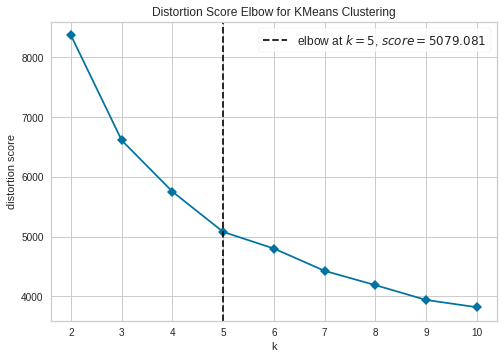

In [ ]:
# https://blog.cambridgespark.com/how-to-determine-the-optimal-number-of-clusters-for-k-means-clustering-14f27070048f
plot_model(kmeans, plot = 'elbow')

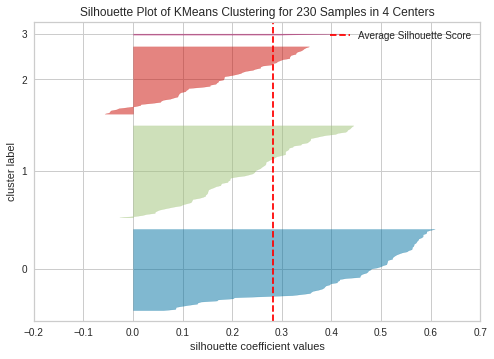

In [ ]:
# https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
plot_model(kmeans, plot = 'silhouette')

In [ ]:
plot_model(kmeans, plot = 'distribution')

In [ ]:
plot_model(kmeans, plot = 'distribution', feature = 'Country Name')

## Execução do modelo em dados "não vistos" pelo algoritmo

In [ ]:
from pycaret.clustering import predict_model
predict_model(kmeans, data = base2)

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,Cluster
20,Low & middle income,1.303926,1.860753,2.338774,2.311674,2.328088,2.424018,2.367054,2.379383,2.416060,2.419304,2.419175,2.338935,2.283149,2.217386,2.129308,2.067948,2.010133,2.003959,2.008993,1.996260,2.004685,2.059897,2.049269,2.011230,2.017682,2.041829,2.058015,2.034866,1.982682,1.956973,1.843339,1.772830,1.719786,1.684732,1.651358,1.623468,1.600652,1.564867,1.519778,1.484852,1.442530,1.404199,1.388844,1.373042,1.359510,1.341320,1.321013,1.318521,1.322586,1.321704,1.323835,1.322282,1.321783,1.316720,1.303585,Cluster 1
25,Middle East & North Africa (IDA & IBRD countries),2.661590,2.669360,2.678723,2.693598,2.709831,2.730300,2.741881,2.728886,2.686437,2.629433,2.561290,2.528479,2.530104,2.573330,2.645002,2.714810,2.778539,2.852824,2.936775,3.020601,3.096739,3.150248,3.172405,3.136388,3.136021,3.094988,3.016612,2.912087,2.741110,2.624816,2.440988,2.293666,2.139133,2.123760,2.065970,2.021585,1.985844,1.942990,1.892519,1.825578,1.769651,1.726221,1.701742,1.707204,1.731337,1.760660,1.782840,1.799052,1.802216,1.792764,1.787035,1.770190,1.763456,1.758094,1.753158,Cluster 1
37,Sub-Saharan Africa (excluding high income),2.405521,2.414234,2.428269,2.446306,2.467617,2.492378,2.519372,2.546593,2.573163,2.599470,2.631405,2.652251,2.677869,2.710330,2.746171,2.781224,2.809059,2.830760,2.849029,2.860953,2.866082,2.870151,2.875462,2.884350,2.892057,2.896258,2.893459,2.882993,2.864358,2.838175,2.829848,2.820757,2.804985,2.783158,2.756811,2.734563,2.717947,2.709746,2.713710,2.724962,2.703934,2.655090,2.674876,2.694924,2.717086,2.738630,2.756686,2.769071,2.774611,2.774653,2.772228,2.768171,2.759708,2.747007,2.730999,Cluster 2
71,Burkina Faso,1.342840,1.334320,1.351483,1.403717,1.479076,1.562532,1.635169,1.689184,1.717433,1.729210,1.741006,1.762899,1.791798,1.830496,1.878002,1.922869,1.971188,2.040063,2.133604,2.240725,2.351180,2.447876,2.519603,2.559783,2.577848,2.590133,2.605947,2.621695,2.639705,2.659117,2.677002,2.692954,2.709583,2.727333,2.745914,2.765532,2.785272,2.804101,2.821700,2.839111,2.851760,2.865869,2.891739,2.932051,2.978598,3.025356,3.059559,3.072128,3.058629,3.027773,2.992039,2.960440,2.932567,2.911018,2.893466,Cluster 2
72,Burundi,1.906363,1.887975,1.929539,2.047881,2.202588,2.401721,2.543444,2.508815,2.254373,1.873439,1.449620,1.126657,0.999042,1.135078,1.455693,1.824568,2.134456,2.386212,2.546783,2.642530,2.704589,2.778452,2.882741,3.029548,3.184501,3.340363,3.427948,3.379445,3.172025,2.867408,2.572788,2.328842,2.094406,1.878294,1.697097,1.501486,1.364037,1.415439,1.702084,2.141346,2.620096,3.022892,3.314565,3.457836,3.496163,3.515122,3.544436,3.544561,3.519276,3.477233,3.418643,3.358846,3.316265,3.297804,3.292392,Cluster 2
79,Chad,1.940259,1.970832,1.979348,1.959559,1.924917,1.874306,1.840461,1.861116,1.951818,2.082854,2.237416,2.357499,2.393115,2.320985,2.184361,2.038626,1.938873,1.900127,1.942527,2.044945,2.152025,2.253952,2.388139,2.555707,2.738340,2.931637,3.100038,3.206389,3.236711,3.219247,3.191075,3.183292,3.199423,3.248303,3.318408,3.375635,3.422189,3.488078,3.576390,3.669487,3.766889,3.832788,3.829421,3.745525,3.614775,3.471868,3.357255,3.287234,3.274381,3.297145,3.324413,3.334069,3.328243,3.301595,3.261297,Cluster 2
101,Equatorial Guinea,1.177029,1.107137,1.175509,1.427745,1.753794,2.218125,2.500511,2.190771,1.141020,-0.380499,-2.080586,-3.576167,-4.656297,-5.005869,-4.652898,-4.178175,-3.627055,-2.326818,-0.125494,2.567063,5.438138,7.589627,8.354904,7.707993,6.340793,4.915253,3.873471,3.209892,3.045771,3.207538,3.391560,3.449217,3.484407,3.473317,3.434144,3.401426,3.389609,3.379665,3.371100,3.361412,3.354505,3.341850,3.310663,3.257529,3.192468,3.122659,3.062345,3.021633,3.004723,3.002597,3.002061,2.992523,2.973588,2.94254

## Salvar o modelo

In [ ]:
from pycaret.clustering import save_model
save_model(kmeans,'kmeans_final')

Transformation Pipeline and Model Succesfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=[],
                                       display_types=True,
                                       features_todrop=['Country Name'],
                                       id_columns=[], ml_usecase='regression',
                                       numerical_features=[],
                                       target='UNSUPERVISED_DUMMY_TARGET',
                                       time_features=[])),
                 ('imputer',
                  Simple_Imputer(categorical_strategy='most frequent',
                                 fill_value_categorical=None,
                                 fill_value_n...
                 ('fix_perfect', 'passthrough'),
                 ('clean_names', Clean_Colum_Names()),
                 ('feature_select', 'passthrough'), ('fix_multi', 'passthrough'),
                 ('dfs', 'passthrough'), ('pca', 'passthrough'),
                

In [ ]:
from pycaret.clustering import load_model
kmeans_carregado = load_model('/content/kmeans_final')

Transformation Pipeline and Model Successfully Loaded


In [ ]:
previsoes = predict_model(kmeans_carregado, data=base2)
previsoes

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,Cluster
20,Low & middle income,1.303926,1.860753,2.338774,2.311674,2.328088,2.424018,2.367054,2.379383,2.416060,2.419304,2.419175,2.338935,2.283149,2.217386,2.129308,2.067948,2.010133,2.003959,2.008993,1.996260,2.004685,2.059897,2.049269,2.011230,2.017682,2.041829,2.058015,2.034866,1.982682,1.956973,1.843339,1.772830,1.719786,1.684732,1.651358,1.623468,1.600652,1.564867,1.519778,1.484852,1.442530,1.404199,1.388844,1.373042,1.359510,1.341320,1.321013,1.318521,1.322586,1.321704,1.323835,1.322282,1.321783,1.316720,1.303585,Cluster 1
25,Middle East & North Africa (IDA & IBRD countries),2.661590,2.669360,2.678723,2.693598,2.709831,2.730300,2.741881,2.728886,2.686437,2.629433,2.561290,2.528479,2.530104,2.573330,2.645002,2.714810,2.778539,2.852824,2.936775,3.020601,3.096739,3.150248,3.172405,3.136388,3.136021,3.094988,3.016612,2.912087,2.741110,2.624816,2.440988,2.293666,2.139133,2.123760,2.065970,2.021585,1.985844,1.942990,1.892519,1.825578,1.769651,1.726221,1.701742,1.707204,1.731337,1.760660,1.782840,1.799052,1.802216,1.792764,1.787035,1.770190,1.763456,1.758094,1.753158,Cluster 1
37,Sub-Saharan Africa (excluding high income),2.405521,2.414234,2.428269,2.446306,2.467617,2.492378,2.519372,2.546593,2.573163,2.599470,2.631405,2.652251,2.677869,2.710330,2.746171,2.781224,2.809059,2.830760,2.849029,2.860953,2.866082,2.870151,2.875462,2.884350,2.892057,2.896258,2.893459,2.882993,2.864358,2.838175,2.829848,2.820757,2.804985,2.783158,2.756811,2.734563,2.717947,2.709746,2.713710,2.724962,2.703934,2.655090,2.674876,2.694924,2.717086,2.738630,2.756686,2.769071,2.774611,2.774653,2.772228,2.768171,2.759708,2.747007,2.730999,Cluster 2
71,Burkina Faso,1.342840,1.334320,1.351483,1.403717,1.479076,1.562532,1.635169,1.689184,1.717433,1.729210,1.741006,1.762899,1.791798,1.830496,1.878002,1.922869,1.971188,2.040063,2.133604,2.240725,2.351180,2.447876,2.519603,2.559783,2.577848,2.590133,2.605947,2.621695,2.639705,2.659117,2.677002,2.692954,2.709583,2.727333,2.745914,2.765532,2.785272,2.804101,2.821700,2.839111,2.851760,2.865869,2.891739,2.932051,2.978598,3.025356,3.059559,3.072128,3.058629,3.027773,2.992039,2.960440,2.932567,2.911018,2.893466,Cluster 2
72,Burundi,1.906363,1.887975,1.929539,2.047881,2.202588,2.401721,2.543444,2.508815,2.254373,1.873439,1.449620,1.126657,0.999042,1.135078,1.455693,1.824568,2.134456,2.386212,2.546783,2.642530,2.704589,2.778452,2.882741,3.029548,3.184501,3.340363,3.427948,3.379445,3.172025,2.867408,2.572788,2.328842,2.094406,1.878294,1.697097,1.501486,1.364037,1.415439,1.702084,2.141346,2.620096,3.022892,3.314565,3.457836,3.496163,3.515122,3.544436,3.544561,3.519276,3.477233,3.418643,3.358846,3.316265,3.297804,3.292392,Cluster 2
79,Chad,1.940259,1.970832,1.979348,1.959559,1.924917,1.874306,1.840461,1.861116,1.951818,2.082854,2.237416,2.357499,2.393115,2.320985,2.184361,2.038626,1.938873,1.900127,1.942527,2.044945,2.152025,2.253952,2.388139,2.555707,2.738340,2.931637,3.100038,3.206389,3.236711,3.219247,3.191075,3.183292,3.199423,3.248303,3.318408,3.375635,3.422189,3.488078,3.576390,3.669487,3.766889,3.832788,3.829421,3.745525,3.614775,3.471868,3.357255,3.287234,3.274381,3.297145,3.324413,3.334069,3.328243,3.301595,3.261297,Cluster 2
101,Equatorial Guinea,1.177029,1.107137,1.175509,1.427745,1.753794,2.218125,2.500511,2.190771,1.141020,-0.380499,-2.080586,-3.576167,-4.656297,-5.005869,-4.652898,-4.178175,-3.627055,-2.326818,-0.125494,2.567063,5.438138,7.589627,8.354904,7.707993,6.340793,4.915253,3.873471,3.209892,3.045771,3.207538,3.391560,3.449217,3.484407,3.473317,3.434144,3.401426,3.389609,3.379665,3.371100,3.361412,3.354505,3.341850,3.310663,3.257529,3.192468,3.122659,3.062345,3.021633,3.004723,3.002597,3.002061,2.992523,2.973588,2.94254